# Course 3: Unsupervised Learning, Recommenders, Reinforcement Learning

## Complete Summary with Theory and Practice

This comprehensive notebook summarizes all key concepts from Course 3 of the Machine Learning Specialization, covering unsupervised learning algorithms, recommender systems, and reinforcement learning.

---

## Table of Contents
1. [Clustering (K-Means)](#clustering)
2. [Anomaly Detection](#anomaly)
3. [Collaborative Filtering](#collaborative)
4. [Content-Based Filtering](#content-based)
5. [Reinforcement Learning Fundamentals](#rl-fundamentals)
6. [Continuous State Spaces](#continuous-state)

---

<a name="clustering"></a>
## 1. Clustering with K-Means

### What is Unsupervised Learning?

**Supervised Learning**: Data comes with labels ( $\{(x^{(i)}, y^{(i)})\}$ )
**Unsupervised Learning**: Data has NO labels ( $\{x^{(i)}\}$ only)

**Goal**: Find hidden structure/patterns in data

**Applications:**
- Customer segmentation
- Organizing data (e.g., grouping news articles)
- Dimensionality reduction
- Anomaly detection

### K-Means Clustering

**Goal**: Partition data into K clusters (groups of similar points)

**Algorithm:**

**Input**: K (number of clusters), Training set $\{x^{(1)}, ..., x^{(m)}\}$

**Initialize**: Randomly pick K cluster centroids $\mu_1, ..., \mu_K$

**Repeat until convergence:**
1. **Assignment step**: Assign each point to nearest centroid
   $$c^{(i)} = \arg\min_k ||x^{(i)} - \mu_k||^2$$
   
2. **Update step**: Move centroids to mean of assigned points
   $$\mu_k = \frac{1}{|C_k|}\sum_{i \in C_k} x^{(i)}$$

Where:
- $c^{(i)}$ = index of cluster assigned to example $i$
- $\mu_k$ = cluster centroid $k$
- $C_k$ = set of examples assigned to cluster $k$

### K-Means Cost Function (Distortion)

$$J(c^{(1)}, ..., c^{(m)}, \mu_1, ..., \mu_K) = \frac{1}{m}\sum_{i=1}^{m} ||x^{(i)} - \mu_{c^{(i)}}||^2$$

**Objective**: Minimize the sum of squared distances from points to their assigned centroids

### Initializing K-Means

**Random Initialization** (recommended):
1. Choose K < m (number of training examples)
2. Randomly pick K training examples
3. Set $\mu_1, ..., \mu_K$ equal to these examples

**Problem**: K-means can get stuck in local minima!

**Solution**: Run K-means multiple times with different random initializations
- Run 50-1000 times
- Pick clustering with lowest cost $J$

### Choosing the Number of Clusters K

**Elbow Method**:
1. Run K-means for K = 1, 2, 3, ..., 10
2. Plot cost $J$ vs K
3. Look for "elbow" where cost stops decreasing rapidly
4. Choose K at the elbow

**Limitation**: Elbow often not clear!

**Better approach**: Choose K based on downstream purpose
- Example: T-shirt sizes → K = 3 (S, M, L) or K = 5 (XS, S, M, L, XL)
- Choose based on what makes sense for your application

Dataset shape: (300, 2)
Number of examples: 300


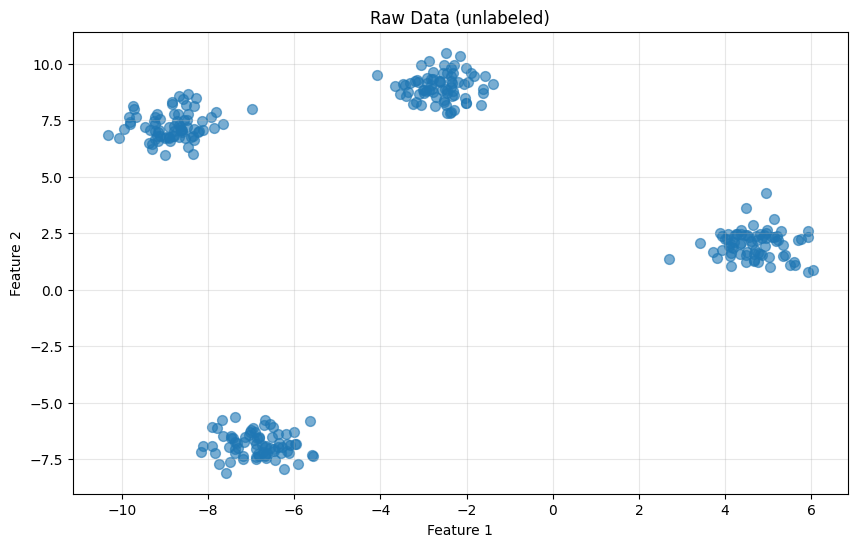


K-Means Algorithm (K=4)
Final cost (distortion): 0.6796

Centroid locations:
[[ 4.68687447  2.01434593]
 [-6.85126211 -6.85031833]
 [-2.60516878  8.99280115]
 [-8.83456141  7.24430734]]


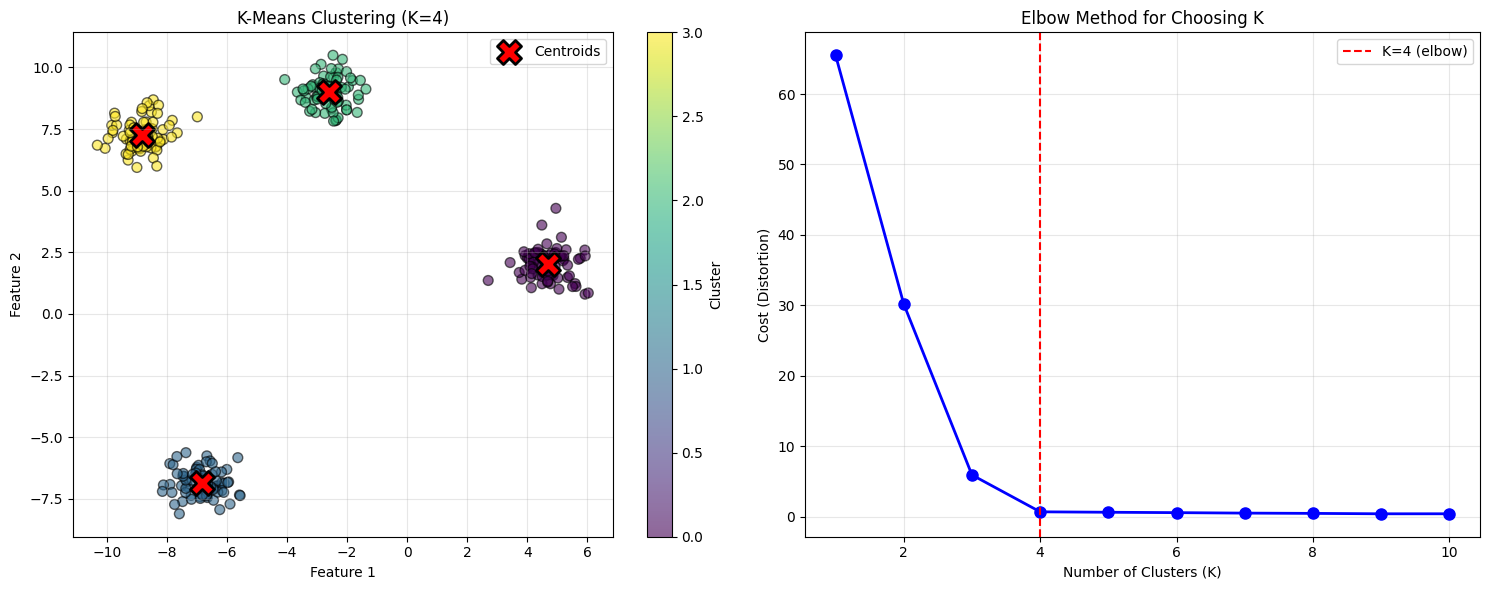


Comparison with sklearn:
Our implementation cost: 0.6796
Sklearn inertia: 0.6796
Results match: True


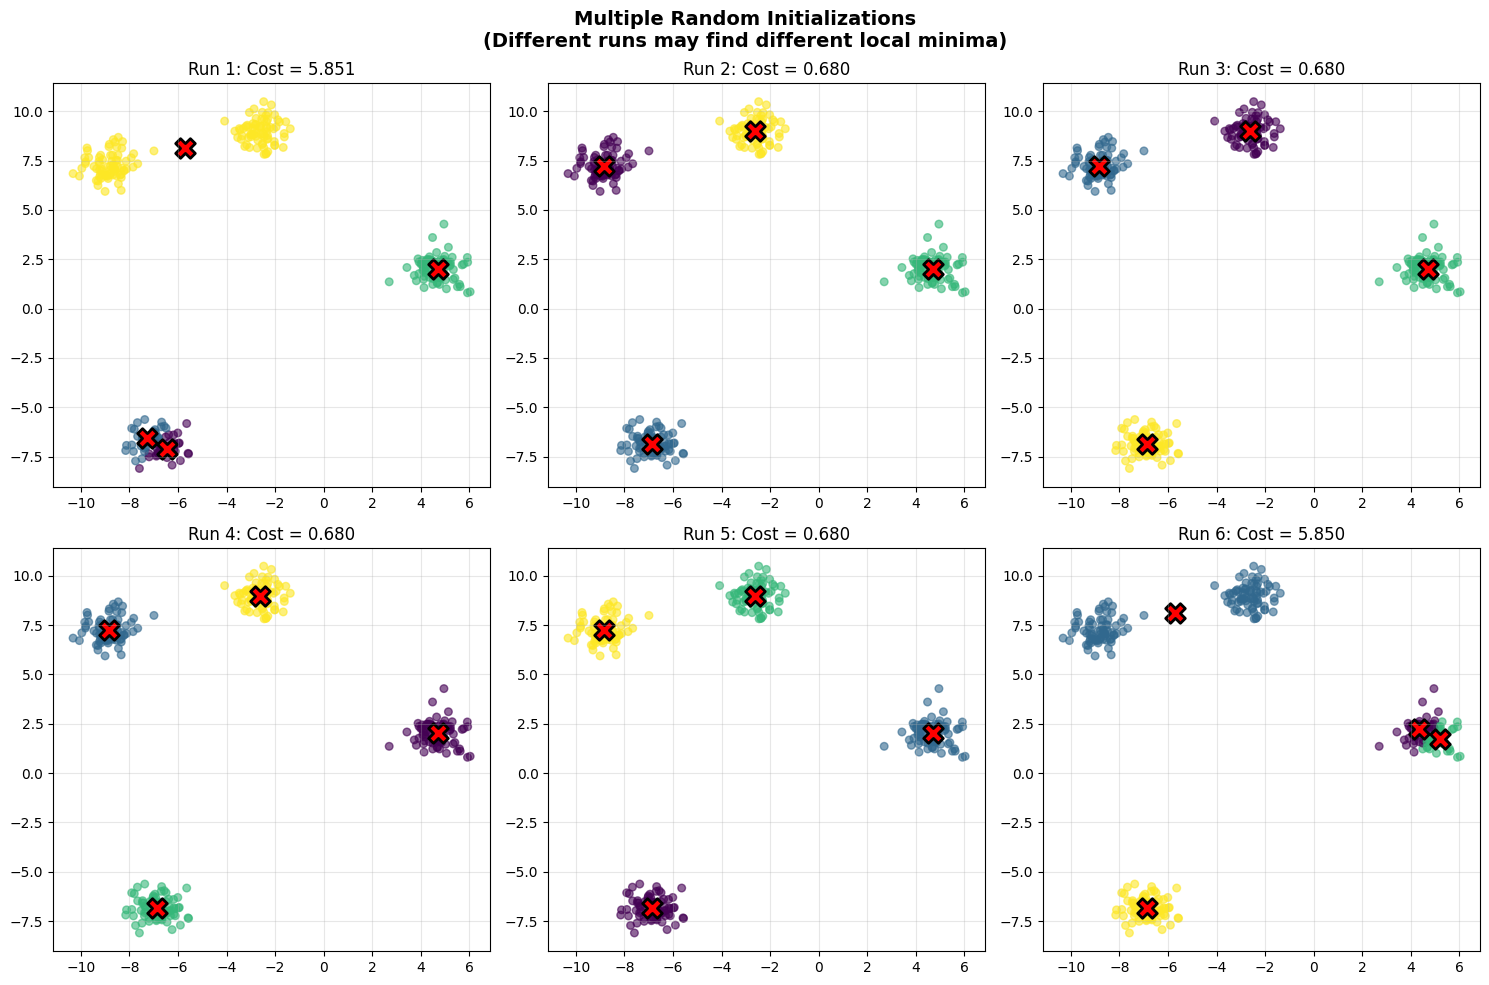


Key Takeaway: Run K-means multiple times with different
random initializations and pick the solution with lowest cost!


In [3]:
### Code Example: K-Means Clustering from Scratch

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)

# Generate synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=4, n_features=2, 
                       cluster_std=0.60, random_state=42)

print(f"Dataset shape: {X.shape}")
print(f"Number of examples: {len(X)}")

# Visualize raw data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Raw Data (unlabeled)')
plt.grid(True, alpha=0.3)
plt.show()

# K-Means Implementation
class KMeans:
    def __init__(self, K=3, max_iters=100, n_init=10):
        self.K = K
        self.max_iters = max_iters
        self.n_init = n_init
        
    def initialize_centroids(self, X):
        """Randomly initialize K centroids from data points"""
        random_indices = np.random.choice(X.shape[0], self.K, replace=False)
        centroids = X[random_indices]
        return centroids
    
    def assign_clusters(self, X, centroids):
        """Assign each point to nearest centroid"""
        distances = np.zeros((X.shape[0], self.K))
        
        for k in range(self.K):
            distances[:, k] = np.linalg.norm(X - centroids[k], axis=1)
        
        cluster_assignments = np.argmin(distances, axis=1)
        return cluster_assignments
    
    def update_centroids(self, X, cluster_assignments):
        """Update centroids to mean of assigned points"""
        centroids = np.zeros((self.K, X.shape[1]))
        
        for k in range(self.K):
            cluster_points = X[cluster_assignments == k]
            if len(cluster_points) > 0:
                centroids[k] = np.mean(cluster_points, axis=0)
        
        return centroids
    
    def compute_cost(self, X, centroids, cluster_assignments):
        """Compute distortion (cost function)"""
        cost = 0
        for i in range(len(X)):
            cost += np.linalg.norm(X[i] - centroids[cluster_assignments[i]])**2
        return cost / len(X)
    
    def fit(self, X):
        """Run K-means algorithm with multiple initializations"""
        best_cost = float('inf')
        best_centroids = None
        best_assignments = None
        
        for init in range(self.n_init):
            # Initialize centroids
            centroids = self.initialize_centroids(X)
            
            # Run K-means
            for iteration in range(self.max_iters):
                # Assignment step
                cluster_assignments = self.assign_clusters(X, centroids)
                
                # Update step
                new_centroids = self.update_centroids(X, cluster_assignments)
                
                # Check convergence
                if np.allclose(centroids, new_centroids):
                    break
                
                centroids = new_centroids
            
            # Compute cost
            cost = self.compute_cost(X, centroids, cluster_assignments)
            
            # Keep best result
            if cost < best_cost:
                best_cost = cost
                best_centroids = centroids
                best_assignments = cluster_assignments
        
        self.centroids = best_centroids
        self.labels_ = best_assignments
        self.cost = best_cost
        
        return self
    
    def predict(self, X):
        """Predict cluster for new data points"""
        return self.assign_clusters(X, self.centroids)

# Run K-Means
K = 4
kmeans = KMeans(K=K, max_iters=100, n_init=10)
kmeans.fit(X)

print(f"\nK-Means Algorithm (K={K})")
print(f"Final cost (distortion): {kmeans.cost:.4f}")
print(f"\nCentroid locations:")
print(kmeans.centroids)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot clustering result
ax = axes[0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, 
                    cmap='viridis', s=50, alpha=0.6, edgecolors='black')
ax.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
          c='red', marker='X', s=300, edgecolors='black', linewidths=2,
          label='Centroids')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title(f'K-Means Clustering (K={K})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Cluster')

# Plot: Choosing K (Elbow method)
ax = axes[1]
K_range = range(1, 11)
costs = []

for k in K_range:
    temp_kmeans = KMeans(K=k, max_iters=100, n_init=5)
    temp_kmeans.fit(X)
    costs.append(temp_kmeans.cost)

ax.plot(K_range, costs, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=4, color='r', linestyle='--', label='K=4 (elbow)')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Cost (Distortion)')
ax.set_title('Elbow Method for Choosing K')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare with sklearn
from sklearn.cluster import KMeans as SKLearnKMeans

sklearn_kmeans = SKLearnKMeans(n_clusters=K, n_init=10, random_state=42)
sklearn_kmeans.fit(X)

print(f"\nComparison with sklearn:")
print(f"Our implementation cost: {kmeans.cost:.4f}")
print(f"Sklearn inertia: {sklearn_kmeans.inertia_ / len(X):.4f}")
print(f"Results match: {np.allclose(kmeans.cost, sklearn_kmeans.inertia_ / len(X), rtol=0.1)}")

# Demonstrate the effect of initialization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(6):
    kmeans_single = KMeans(K=K, max_iters=100, n_init=1)  # Only 1 initialization
    kmeans_single.fit(X)
    
    ax = axes[i]
    ax.scatter(X[:, 0], X[:, 1], c=kmeans_single.labels_, 
              cmap='viridis', s=30, alpha=0.6)
    ax.scatter(kmeans_single.centroids[:, 0], kmeans_single.centroids[:, 1],
              c='red', marker='X', s=200, edgecolors='black', linewidths=2)
    ax.set_title(f'Run {i+1}: Cost = {kmeans_single.cost:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Multiple Random Initializations\n(Different runs may find different local minima)', 
            fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Key Takeaway: Run K-means multiple times with different")
print("random initializations and pick the solution with lowest cost!")
print("="*60)

<a name="anomaly"></a>
## 2. Anomaly Detection

### What is Anomaly Detection?

**Goal**: Identify unusual/rare events in data

**Applications:**
- Fraud detection (unusual credit card transactions)
- Manufacturing (detecting defective products)
- Monitoring systems (detecting failing servers)
- Healthcare (unusual patient conditions)

### Gaussian (Normal) Distribution

Anomaly detection often uses the **Gaussian distribution**:

$$p(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Where:
- $\mu$ = mean
- $\sigma^2$ = variance
- $\sigma$ = standard deviation

**Estimate parameters from data:**
$$\mu = \frac{1}{m}\sum_{i=1}^{m}x^{(i)}$$
$$\sigma^2 = \frac{1}{m}\sum_{i=1}^{m}(x^{(i)} - \mu)^2$$

### Anomaly Detection Algorithm

**Training**: Given unlabeled dataset $\{x^{(1)}, ..., x^{(m)}\}$

1. **Choose features** $x_j$ that might be indicative of anomalies

2. **Fit parameters** $\mu_1, ..., \mu_n$ and $\sigma_1^2, ..., \sigma_n^2$:
   $$\mu_j = \frac{1}{m}\sum_{i=1}^{m}x_j^{(i)}$$
   $$\sigma_j^2 = \frac{1}{m}\sum_{i=1}^{m}(x_j^{(i)} - \mu_j)^2$$

3. **Compute probability** for new example $x$:
   $$p(x) = \prod_{j=1}^{n}p(x_j; \mu_j, \sigma_j^2)$$
   
4. **Predict anomaly** if $p(x) < \epsilon$ (threshold)

**Assumption**: Features are independent (simplification, works well in practice)

### Choosing the Threshold $\epsilon$

Use a **labeled validation set** with some anomalies:

1. Train on unlabeled data (mostly normal)
2. Use validation set with labelled anomalies to tune $\epsilon$
3. Choose $\epsilon$ that maximizes F1-score on validation set

**Why F1-score?** Often very skewed classes (few anomalies), so accuracy is misleading

$$\text{F1-score} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

### Anomaly Detection vs Supervised Learning

**Use Anomaly Detection when:**
- Very few positive examples (anomalies): 0-20
- Many negative examples (normal): 1000s+
- Many different types of anomalies
- Future anomalies may look nothing like current ones

**Examples**: Fraud detection, manufacturing defects

**Use Supervised Learning when:**
- Large number of both positive and negative examples
- Enough positive examples to learn what they look like
- Future positive examples similar to training set

**Examples**: Spam classification, disease diagnosis

### Feature Engineering for Anomaly Detection

**Make features more Gaussian**: Transform non-Gaussian features

Examples:
- $x \to \log(x)$
- $x \to \sqrt{x}$
- $x \to x^{1/3}$

**Create new features**: Combine existing features to capture anomalies

Example monitoring computers:
- $x_1$ = CPU load
- $x_2$ = network traffic
- New feature: $x_3 = \frac{\text{CPU load}}{\text{network traffic}}$ (high value might be anomalous)

<a name="collaborative"></a>
## 3. Recommender Systems - Collaborative Filtering

### Introduction to Recommender Systems

**Goal**: Predict ratings/preferences to recommend items

**Examples:**
- Netflix: Recommend movies/shows
- Amazon: Recommend products
- Spotify: Recommend songs

**Two main approaches:**
1. **Collaborative filtering**: Based on user-item interactions
2. **Content-based filtering**: Based on features of items/users

### Notation for Collaborative Filtering

- $n_u$ = number of users
- $n_m$ = number of items (movies)
- $r(i,j) = 1$ if user $j$ rated item $i$
- $y^{(i,j)}$ = rating given by user $j$ to item $i$
- $\mathbf{x}^{(i)}$ = feature vector for item $i$
- $\mathbf{w}^{(j)}, b^{(j)}$ = parameters for user $j$

### Collaborative Filtering Algorithm

**Idea**: Learn features and parameters simultaneously

**Predict rating** of item $i$ by user $j$:
$$\hat{y}^{(i,j)} = \mathbf{w}^{(j)} \cdot \mathbf{x}^{(i)} + b^{(j)}$$

### Cost Function

$$J = \frac{1}{2}\sum_{(i,j):r(i,j)=1}(\mathbf{w}^{(j)} \cdot \mathbf{x}^{(i)} + b^{(j)} - y^{(i,j)})^2 + \frac{\lambda}{2}\sum_{j=1}^{n_u}\sum_{k=1}^{n}(w_k^{(j)})^2 + \frac{\lambda}{2}\sum_{i=1}^{n_m}\sum_{k=1}^{n}(x_k^{(i)})^2$$

**Sum only over rated items**: $(i,j):r(i,j)=1$

**Regularization**: Prevents overfitting

### Binary Ratings (Liked/Not Liked)

For binary feedback (thumbs up/down, watched/not watched):

Use **logistic-style** prediction:
$$\hat{y}^{(i,j)} = g(\mathbf{w}^{(j)} \cdot \mathbf{x}^{(i)} + b^{(j)})$$

**Cost function** (binary cross-entropy):
$$J = \sum_{(i,j):r(i,j)=1} L(f(\mathbf{x}, \mathbf{w}, b), y^{(i,j)})$$

Where $L$ is the logistic loss.

### Mean Normalization

**Problem**: New user with no ratings will get average predictions

**Solution**: Normalize ratings by subtracting mean

For each movie $i$, compute mean rating $\mu_i$

**Normalized ratings**: $y^{(i,j)} - \mu_i$

**Train on normalized** ratings, then add back mean for predictions:
$$\text{prediction} = \mathbf{w}^{(j)} \cdot \mathbf{x}^{(i)} + b^{(j)} + \mu_i$$

Now new users get mean ratings (reasonable default)

### Finding Similar Items

To find items similar to item $i$:

Compute distance between feature vectors:
$$\text{similarity}(i, k) = ||\mathbf{x}^{(i)} - \mathbf{x}^{(k)}||^2$$

Small distance → similar items

**Use case**: "Users who liked X also liked Y"

<a name="content-based"></a>
## 4. Content-Based Filtering

### Collaborative vs Content-Based

**Collaborative Filtering:**
- Uses user-item interactions only
- "Users similar to you liked..."
- Doesn't need item features
- Cold start problem for new items

**Content-Based Filtering:**
- Uses features of items and users
- "Based on items you liked..."
- Can recommend new items immediately
- Requires feature engineering

### Content-Based Deep Learning Approach

**Architecture**: Two neural networks

1. **User Network**: Takes user features $\mathbf{x}_u$ → outputs $\mathbf{v}_u$
2. **Item Network**: Takes item features $\mathbf{x}_m$ → outputs $\mathbf{v}_m$

**Prediction**: 
$$\hat{y} = \mathbf{v}_u \cdot \mathbf{v}_m$$

**User features** $\mathbf{x}_u$: age, gender, location, past ratings, etc.
**Item features** $\mathbf{x}_m$: genre, year, actors, director, etc.

### Building the Neural Networks

**User Network:**
```python
user_NN = Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(32, activation='linear')  # v_u output (32-dim vector)
])
```

**Item Network:**
```python
item_NN = Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(32, activation='linear')  # v_m output (32-dim vector)
])
```

**Combine**:
```python
v_u = user_NN(user_features)
v_m = item_NN(item_features)
output = tf.reduce_sum(v_u * v_m)  # Dot product
```

### Cost Function

For user $j$ and item $i$:

$$J = \sum_{(i,j):r(i,j)=1}(\mathbf{v}_u^{(j)} \cdot \mathbf{v}_m^{(i)} - y^{(i,j)})^2 + \text{regularization}$$

Train both networks simultaneously with gradient descent!

### Advantages of Content-Based Filtering

1. **Can recommend new items**: No need for ratings history
2. **Can use rich features**: Genre, description, images, etc.
3. **Can provide explanations**: "Because you liked action movies..."
4. **Can work with cold start**: New users/items with features

### Retrieval and Ranking

For large-scale systems (millions of items):

**Two-stage approach:**

1. **Retrieval (candidate generation)**: Quickly find ~100-1000 candidates
   - Find items similar to user's past likes
   - Find most popular items in user's category
   - Use fast approximate nearest neighbor search

2. **Ranking**: Rank candidates using more complex model
   - Use full neural network model
   - Consider many features
   - Return top N items

### TensorFlow Implementation Example

```python
# User network
user_input = tf.keras.Input(shape=(num_user_features,))
user_vec = tf.keras.layers.Dense(256, activation='relu')(user_input)
user_vec = tf.keras.layers.Dense(128, activation='relu')(user_vec)
user_vec = tf.keras.layers.Dense(32, name='user_embedding')(user_vec)

# Item network
item_input = tf.keras.Input(shape=(num_item_features,))
item_vec = tf.keras.layers.Dense(256, activation='relu')(item_input)
item_vec = tf.keras.layers.Dense(128, activation='relu')(item_vec)
item_vec = tf.keras.layers.Dense(32, name='item_embedding')(item_vec)

# Dot product
output = tf.keras.layers.Dot(axes=1)([user_vec, item_vec])

# Create model
model = tf.keras.Model([user_input, item_input], output)
model.compile(optimizer='adam', loss='mse')
```

<a name="rl-fundamentals"></a>
## 5. Reinforcement Learning Fundamentals

### What is Reinforcement Learning?

**Goal**: Learn to make sequences of good decisions

**Key difference from supervised learning:**
- No labeled data (no "correct" action given)
- Learn from rewards/penalties
- Must balance exploration vs exploitation
- Actions affect future states

**Applications:**
- Game playing (chess, Go, video games)
- Robotics (walking, grasping)
- Autonomous driving
- Resource management
- Dialog systems

### Key Concepts

**Agent**: The learner/decision maker (e.g., robot, game player)

**Environment**: What the agent interacts with (e.g., game, physical world)

**State** ($s$): Current situation

**Action** ($a$): What the agent can do

**Reward** ($R(s)$): Feedback signal (positive or negative)

**Policy** ($\pi$): Strategy for choosing actions
- $\pi(s) = a$ means "in state $s$, take action $a$"

**Goal**: Find policy $\pi$ that maximizes **total reward**

### Return

**Return**: Total reward from current time onward

$$\text{Return} = R_1 + R_2 + R_3 + ...$$

**Problem**: Infinite sum for continuing tasks!

**Solution**: **Discount factor** $\gamma$ (0 < $\gamma$ < 1)

$$\text{Return} = R_1 + \gamma R_2 + \gamma^2 R_3 + \gamma^3 R_4 + ...$$

**Typical values**: $\gamma = 0.9, 0.99, 0.999$

**Effect:**
- Rewards now worth more than rewards later
- Makes infinite sums finite
- Encourages getting rewards sooner

### Markov Decision Process (MDP)

**Components:**
- Set of states $S$
- Set of actions $A$
- Transition probabilities $P(s'|s,a)$
- Reward function $R(s, a, s')$
- Discount factor $\gamma$

**Markov property**: Future depends only on current state, not history

### Value Functions

**State-value function** $V(s)$: Expected return starting from state $s$ and following policy $\pi$

$$V^\pi(s) = \mathbb{E}[\text{Return} | s_0 = s, \pi]$$

**Interpretation**: How good is it to be in state $s$?

**Action-value function** $Q(s, a)$: Expected return from state $s$, taking action $a$, then following policy $\pi$

$$Q^\pi(s,a) = \mathbb{E}[\text{Return} | s_0 = s, a_0 = a, \pi]$$

**Interpretation**: How good is taking action $a$ in state $s$?

### Bellman Equation

**Key insight**: Value of a state = immediate reward + discounted value of next state

$$V(s) = R(s) + \gamma \max_{a} \sum_{s'} P(s'|s,a) V(s')$$

For Q-function:
$$Q(s,a) = R(s,a) + \gamma \sum_{s'}P(s'|s,a)\max_{a'}Q(s',a')$$

### Optimal Policy

**Optimal policy** $\pi^*$: Policy that maximizes expected return from all states

**Greedy policy** from $Q$-function:
$$\pi^*(s) = \arg\max_a Q(s,a)$$

**Choose action with highest Q-value!**

### Exploration vs Exploitation

**Exploitation**: Choose action you think is best (greedy)

**Exploration**: Try new actions to learn more

**$\epsilon$-greedy policy:**
- With probability $1-\epsilon$: Pick best action (exploit)
- With probability $\epsilon$: Pick random action (explore)

**Typical**: Start with $\epsilon = 1.0$ (pure exploration), gradually decrease to $\epsilon = 0.01$

<a name="continuous-state"></a>
## 6. Continuous State Spaces and Deep Q-Learning

### The Challenge of Continuous States

**Discrete states**: Finite number (e.g., grid world)
- Can use table to store $Q(s,a)$ for all states

**Continuous states**: Infinite possibilities (e.g., robot position, cart-pole angle)
- Cannot store $Q(s,a)$ in a table!

**Solution**: Use a neural network to approximate $Q(s,a)$!

### Deep Q-Network (DQN)

**Idea**: Train a neural network to approximate $Q(s,a)$

**Input**: State $s$ (e.g., position, velocity, angle)
**Output**: $Q(s,a)$ for each possible action $a$

**Architecture example** (for 4 actions):
```python
model = Sequential([
    Dense(64, activation='relu', input_shape=(state_dim,)),
    Dense(64, activation='relu'),
    Dense(4, activation='linear')  # Output Q-value for each of 4 actions
])
```

Output: $[Q(s, a_1), Q(s, a_2), Q(s, a_3), Q(s, a_4)]$

### Training Deep Q-Networks

**Goal**: Make Q-values satisfy Bellman equation

**Target**: $y = R(s) + \gamma \max_{a'} Q(s', a')$

**Current prediction**: $Q(s, a)$

**Loss**: $L = (y - Q(s,a))^2$ (Mean Squared Error)

### DQN Algorithm

1. **Initialize** Q-network with random weights
2. **Repeat** for many episodes:
   - Start in state $s$
   - **Repeat** for each step:
     - Choose action $a$ using $\epsilon$-greedy policy
     - Take action $a$, observe reward $R$ and next state $s'$
     - Store experience $(s, a, R, s')$ in replay buffer
     - Sample random minibatch from replay buffer
     - For each experience in minibatch:
       - Compute target: $y = R + \gamma \max_{a'} Q(s', a')$
       - Update Q-network to minimize $(y - Q(s,a))^2$
     - Set $s = s'$

### Experience Replay

**Problem**: Training on consecutive samples is inefficient (high correlation)

**Solution**: **Experience replay buffer**
- Store past experiences $(s, a, R, s')$
- Sample random minibatch for training
- Breaks correlation between consecutive samples
- Can reuse experiences multiple times

### Target Network

**Problem**: Target $y$ changes every time we update Q-network (unstable!)

**Solution**: Use **separate target network** $Q_{target}$
- Keep target network fixed for many steps
- Update target network periodically: $Q_{target} \leftarrow Q$
- Makes training more stable

**Target**: $y = R + \gamma \max_{a'} Q_{target}(s', a')$

### Lunar Lander Example

**State**: 8 continuous values (position, velocity, angle, etc.)
**Actions**: 4 discrete actions (do nothing, fire left, fire main, fire right)
**Reward**: Positive for landing, negative for crashing/fuel

**DQN Architecture**:
- Input: 8-dimensional state
- Hidden: 64 units (ReLU)
- Hidden: 64 units (ReLU)  
- Output: 4 Q-values (one per action)

After training: Agent learns to land smoothly!

### Key Insights

**Why Deep RL is hard:**
- Must balance exploration/exploitation
- Delayed rewards (credit assignment problem)
- Moving targets (environment changes as agent learns)
- Sample inefficiency (needs lots of experience)

**What makes DQN work:**
- Neural network function approximation
- Experience replay
- Target network
- Proper hyperparameter tuning

### Summary of Reinforcement Learning

**When to use RL:**
- Sequential decision making
- No direct supervision (no labeled actions)
- Long-term consequences of actions
- Need to explore to find good strategies

**Alternatives when you have labeled data:**
- If you have optimal actions labeled: Use supervised learning!
- If you have human demonstrations: Imitation learning
- If simulator available: Use it for cheap training

---

## Course 3 Summary

**Unsupervised Learning:**
- **K-Means**: Clustering similar data points
- **Anomaly Detection**: Finding rare/unusual patterns

**Recommender Systems:**
- **Collaborative Filtering**: Learn from user-item interactions
- **Content-Based**: Use features of users and items

**Reinforcement Learning:**
- **MDP framework**: States, actions, rewards
- **Q-Learning**: Learn action-value function
- **Deep Q-Networks**: Handle continuous state spaces

**Key Takeaways:**
1. Unsupervised learning finds structure without labels
2. Recommenders predict preferences from past behavior/features
3. RL learns from trial and error to maximize long-term reward
4. Deep learning extends these methods to complex, high-dimensional problems

---

## Congratulations!

You've completed comprehensive summaries of all three courses in the Machine Learning Specialization:

✅ **Course 1**: Supervised Learning (Regression & Classification)
✅ **Course 2**: Neural Networks & Advanced Algorithms
✅ **Course 3**: Unsupervised Learning, Recommenders, RL

**Next steps:**
- Practice on real datasets (Kaggle, UCI ML Repository)
- Build projects to solidify understanding
- Explore advanced topics (transformers, GANs, advanced RL)
- Keep learning and experimenting!

**Happy Learning! 🎉**